In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
import statsmodels.api as sm

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["savefig.facecolor"] = "white"

SEED = 42
N_BOOTSTRAPS = 2_000
FIGURE_DIR = Path("stemness_analysis_figures")
UMAP_DIR = FIGURE_DIR / "umaps"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
UMAP_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, stem, directory=FIGURE_DIR):
    """Export a figure as editable-text SVG and 600-dpi PNG."""
    fig.savefig(
        directory / f"{stem}.svg",
        format="svg",
        dpi=300,
        bbox_inches="tight",
    )
    fig.savefig(
        directory / f"{stem}.png",
        format="png",
        dpi=600,
        bbox_inches="tight",
    )


def rasterize_cell_collections(fig):
    """Rasterize cell layers while retaining vector labels and axes."""
    for axis in fig.axes:
        for collection in axis.collections:
            collection.set_rasterized(True)


## Load the benchmark outputs

Load the trained B2 AnnData object and external stemness scores. The expression
matrix is kept in backed mode because this analysis only needs observation
metadata and the precomputed UMAP embedding.

In [2]:
# Read the benchmark outputs.
plasticity_df = pd.read_csv("plasticity_scores.tsv", sep="\t")
cyto_full = pd.read_csv("../../csvs/Cancer_stemness/cytotrace2_results_full.csv")
stem_df = pd.read_csv("../../csvs/Cancer_stemness/activity_stemness_genesets.csv")
cyto_df = pd.DataFrame({
    "Unnamed: 0": cyto_full["Unnamed: 0"],
    "cytotrace2_score_full": cyto_full["CytoTRACE2_Score"],
})
adata = sc.read_h5ad("final_adata.h5ad", backed="r")

print(f"Cells in AnnData: {adata.n_obs:,}")
print(f"Genes in AnnData: {adata.n_vars:,}")
print("Available observation columns:")
print(sorted(adata.obs.columns.tolist()))

plasticity_df = plasticity_df.merge(
    cyto_df[["Unnamed: 0", "cytotrace2_score_full"]],
    on="Unnamed: 0",
    how="left",
)
plasticity_df = plasticity_df.merge(stem_df, on="Unnamed: 0", how="left")

Cells in AnnData: 33,179
Genes in AnnData: 1,999
Available observation columns:
['Aging_Month', 'Aging_Time', 'Aging_time', 'Batch_Harvest', 'Batch_Library', 'Cluster-Name', 'ES_clone', 'Lane', 'MULTI', 'MetFamily', 'Mouse', 'NUM_INTBC', 'PercentUncut', 'RNA_Present', 'SubTumor', 'TS_Present', 'TS_UMI', 'Tumor', 'clusters', 'entropy', 'genotype', 'is_normal', 'leiden', 'leiden_sub', 'lentiBC', 'librarysize', 'lsd_pseudotime', 'n_counts', 'potential', 'transferred_phylo_pseudotime']


Merge stemness scores to plasticity df

## Merge `scPlasticity` and reproduce the cancer-notebook selection rule

Before computing correlations, we apply the same filtering logic used in the cancer notebook:

1. merge `scPlasticity` onto the cells by ID
2. compute the fraction of non-missing `scPlasticity` values in each cluster
3. retain only clusters with at least 50% valid `scPlasticity`
4. drop any remaining missing values in the analysis columns


In [3]:
# Match the cancer notebook convention for the cell identifier column.
if "Unnamed: 0" in plasticity_df.columns:
    plasticity_cell_col = "Unnamed: 0"
else:
    plasticity_cell_col = plasticity_df.columns[0]

if "scPlasticity" not in plasticity_df.columns:
    raise KeyError("Expected a 'scPlasticity' column in plasticity_scores.tsv")

obs_df = adata.obs[["clusters", "lsd_pseudotime", "entropy"]].copy()
obs_df.index.name = plasticity_cell_col
obs_df = obs_df.reset_index()

merged_df = plasticity_df[
    [
        plasticity_cell_col,
        "scPlasticity",
        "cytotrace2_score_full",
        'score_Malta_2018',
        'CancerSEA_LUAD_Kim_2015',
        'CancerSEA_all',
        'Malta_2018',
        'StemChecker_KEGG',
        'StemChecker_Plurinetwork',
        'StemChecker_hscexplorer',
        'StemChecker_reactome'
    ]
].merge(
    obs_df,
    on=plasticity_cell_col,
    how="inner",
)


# Attach scPlasticity back to AnnData for embedding plots.
for col in [
    "scPlasticity",
    "cytotrace2_score_full",
    'score_Malta_2018',
    'CancerSEA_LUAD_Kim_2015',
    'CancerSEA_all',
    'Malta_2018',
    'StemChecker_KEGG',
    'StemChecker_Plurinetwork',
    'StemChecker_hscexplorer',
    'StemChecker_reactome'
]:
    adata.obs[col] = pd.Series(
        merged_df[col].values,
        index=merged_df[plasticity_cell_col].values,
    ).reindex(adata.obs_names)

# Reproduce the valid-cluster selection process from the cancer notebook.
# Important: the fraction is computed on the full AnnData table after alignment,
# not on the pre-filtered merge alone. This means cells without scPlasticity still
# count against a cluster when deciding whether that cluster is retained.
df_full = adata.obs[["clusters", "lsd_pseudotime", "entropy", "scPlasticity",
                     "cytotrace2_score_full", 
                     'score_Malta_2018', 'CancerSEA_LUAD_Kim_2015', 
                     'CancerSEA_all', 'Malta_2018', 'StemChecker_KEGG',
                     'StemChecker_Plurinetwork', 'StemChecker_hscexplorer',
                     'StemChecker_reactome']].copy()
df_full["clusters"] = df_full["clusters"].astype(str)

cluster_valid_fraction = (
    df_full.groupby("clusters", observed=False)["scPlasticity"]
    .apply(lambda x: x.notna().mean())
    .sort_values(ascending=False)
)

valid_clusters = cluster_valid_fraction[cluster_valid_fraction >= 0.5].index

analysis_df = df_full[df_full["clusters"].isin(valid_clusters)].dropna(
    subset=["scPlasticity", "lsd_pseudotime", "entropy", "cytotrace2_score_full", 
            'score_Malta_2018', 'CancerSEA_LUAD_Kim_2015',
            'CancerSEA_all', 'Malta_2018', 'StemChecker_KEGG',
            'StemChecker_Plurinetwork', 'StemChecker_hscexplorer',
            'StemChecker_reactome']
).copy()

print(f"Cells after merge: {len(merged_df):,}")
print(f"Valid clusters (>= 50% non-missing scPlasticity): {len(valid_clusters)}")
print(f"Cells retained for correlation/regression analysis: {len(analysis_df):,}")

display(cluster_valid_fraction.to_frame(name="valid_cluster_fraction"))


Cells after merge: 16,793
Valid clusters (>= 50% non-missing scPlasticity): 8
Cells retained for correlation/regression analysis: 15,265


,valid_cluster_fraction
clusters,
Late Gastric,0.945378
AT2-like,0.834617
Early gastric,0.787322
Lung progenitor-like,0.786355
AT1-like,0.786156
Early EMT-1,0.752330
High plasticity,0.580973
Gastric-like,0.560842
Endoderm-like,0.130850


## UMAP overview and individual exports

The overview retains the exploratory panels from the source notebook. Cell
points are rasterized in SVG exports, while titles, axes, and color-bar text
remain vector elements. Each UMAP is also exported separately under
`stemness_analysis_figures/umaps`.

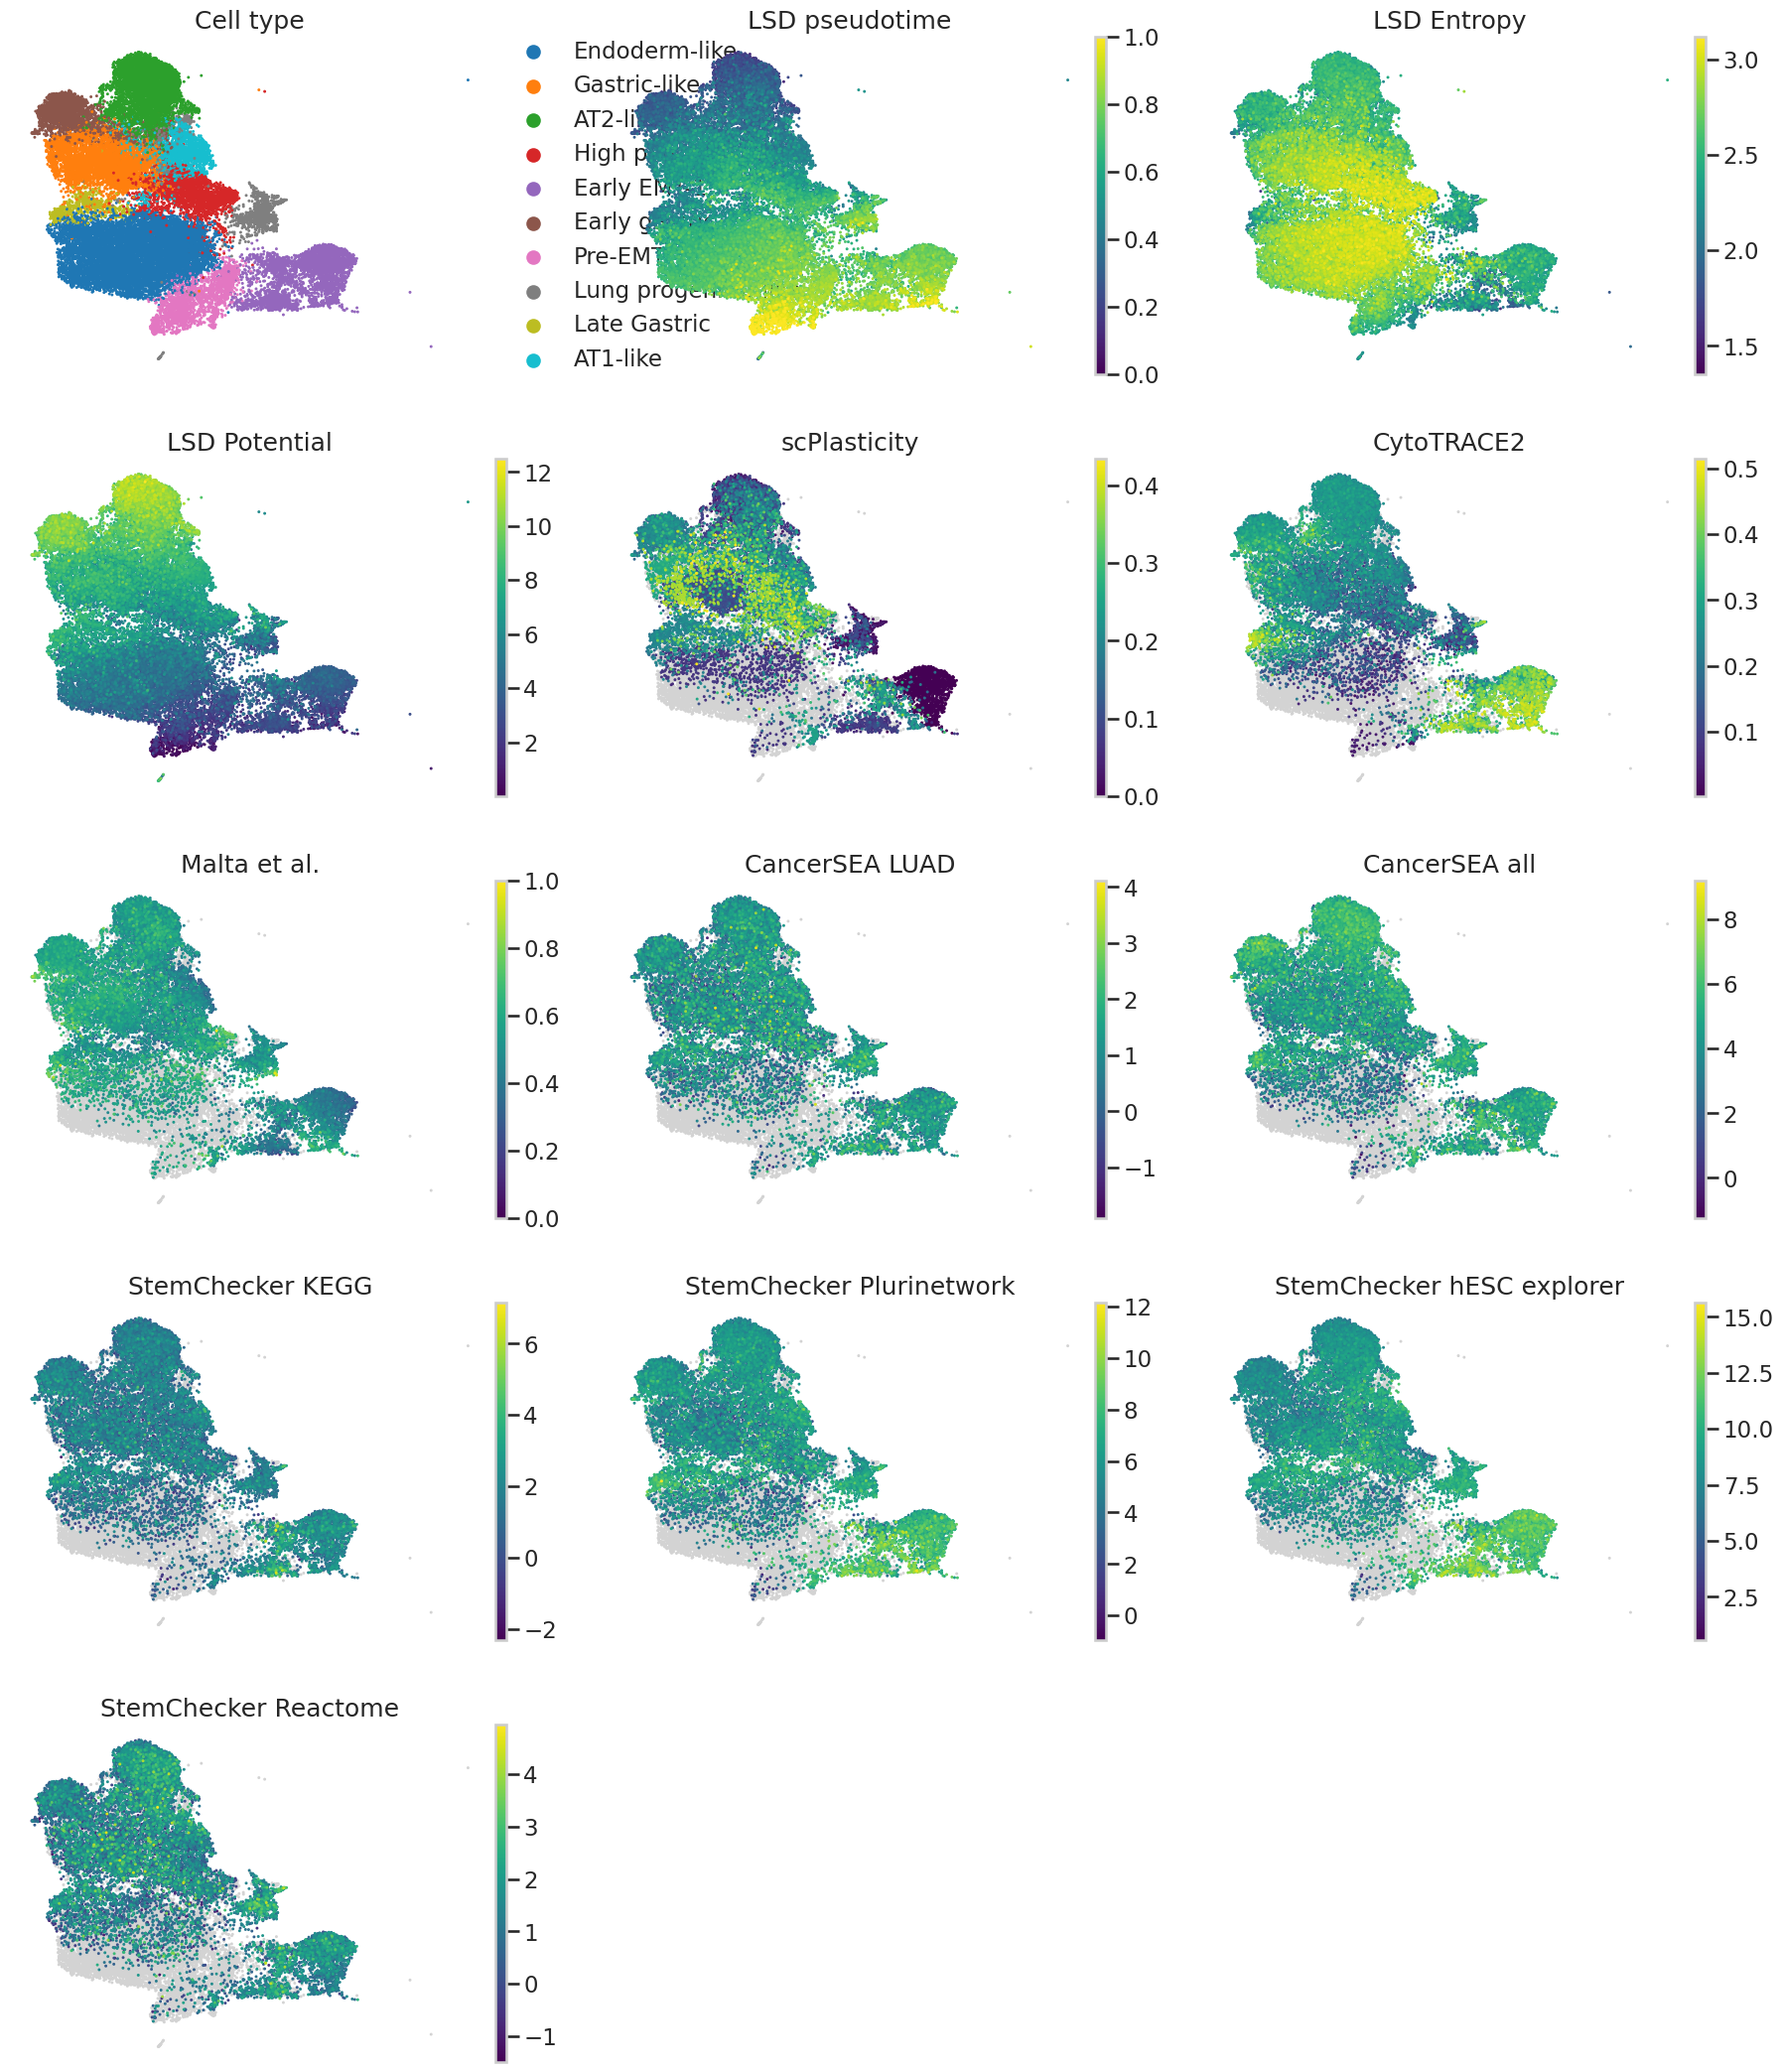

In [12]:
UMAP_SPECS = [
    {"column": "clusters", "title": "Cell type", "stem": "umap_clusters"},
    {"column": "lsd_pseudotime", "title": "LSD pseudotime", "stem": "umap_lsd_pseudotime"},
    {"column": "entropy", "title": "LSD Entropy", "stem": "umap_lsd_entropy"},
    {"column": "potential", "title": "LSD Potential", "stem": "umap_potential"},
    {"column": "scPlasticity", "title": "scPlasticity", "stem": "umap_scplasticity"},
    {"column": "cytotrace2_score_full", "title": "CytoTRACE2", "stem": "umap_cytotrace2"},
    {"column": "score_Malta_2018", "title": "Malta et al.", "stem": "umap_malta_2018"},
    {"column": "CancerSEA_LUAD_Kim_2015", "title": "CancerSEA LUAD", "stem": "umap_cancersea_luad"},
    {"column": "CancerSEA_all", "title": "CancerSEA all", "stem": "umap_cancersea_all"},
    {"column": "StemChecker_KEGG", "title": "StemChecker KEGG", "stem": "umap_stemchecker_kegg"},
    {"column": "StemChecker_Plurinetwork", "title": "StemChecker Plurinetwork", "stem": "umap_stemchecker_plurinetwork"},
    {"column": "StemChecker_hscexplorer", "title": "StemChecker hESC explorer", "stem": "umap_stemchecker_hscexplorer"},
    {"column": "StemChecker_reactome", "title": "StemChecker Reactome", "stem": "umap_stemchecker_reactome"},
]

umap_fig = sc.pl.umap(
    adata,
    color=[spec["column"] for spec in UMAP_SPECS],
    title=[spec["title"] for spec in UMAP_SPECS],
    cmap="viridis",
    frameon=False,
    ncols=3,
    size=18,
    return_fig=True,
    show=False,
)

# Rasterize every cell collection, including categorical cluster points.
rasterize_cell_collections(umap_fig)

save_figure(umap_fig, "umap_overview")
plt.show()

# Export each UMAP independently for flexible figure assembly.
for spec in UMAP_SPECS:
    individual_fig, individual_ax = plt.subplots(figsize=(5.4, 4.8))
    sc.pl.umap(
        adata,
        color=spec["column"],
        title=spec["title"],
        cmap="viridis",
        frameon=False,
        size=18,
        ax=individual_ax,
        show=False,
    )
    rasterize_cell_collections(individual_fig)
    individual_fig.tight_layout()
    save_figure(individual_fig, spec["stem"], directory=UMAP_DIR)
    plt.close(individual_fig)

## Correlation and bootstrap helpers

All Pearson comparisons use the same filtered cells. The bootstrap resamples
cells with replacement and computes all methods on each shared resample, making
the method distributions directly comparable.

In [5]:
METHOD_SPECS = [
    {"column": "lsd_pseudotime", "label": "LSD pseudotime", "slug": "lsd_pseudotime", "color": "#2C7FB8"},
    {"column": "entropy", "label": "LSD Entropy", "slug": "entropy", "color": "#31A354"},
    {"column": "cytotrace2_score_full", "label": "CytoTRACE2", "slug": "cytotrace2", "color": "#756BB1"},
    {"column": "score_Malta_2018", "label": "Malta et al.", "slug": "malta_2018", "color": "#E6550D"},
    {"column": "CancerSEA_LUAD_Kim_2015", "label": "CancerSEA LUAD", "slug": "cancersea_luad", "color": "#636363"},
    {"column": "CancerSEA_all", "label": "CancerSEA all", "slug": "cancersea_all", "color": "#969696"},
    {"column": "StemChecker_KEGG", "label": "StemChecker KEGG", "slug": "stemchecker_kegg", "color": "#1B9E77"},
    {"column": "StemChecker_Plurinetwork", "label": "StemChecker Plurinetwork", "slug": "stemchecker_plurinetwork", "color": "#D95F02"},
    {"column": "StemChecker_hscexplorer", "label": "StemChecker hESC explorer", "slug": "stemchecker_hscexplorer", "color": "#7570B3"},
    {"column": "StemChecker_reactome", "label": "StemChecker Reactome", "slug": "stemchecker_reactome", "color": "#E7298A"},
]


def plot_scplasticity_relationship(df, method):
    """Plot a cell-level relationship and return its Pearson statistics."""
    x_col = method["column"]
    label = method["label"]
    pearson_r, pearson_p = pearsonr(df[x_col], df["scPlasticity"])

    fig, ax = plt.subplots(figsize=(7.2, 5.4))
    sns.regplot(
        data=df,
        x=x_col,
        y="scPlasticity",
        scatter_kws={
            "alpha": 0.30,
            "s": 12,
            "color": method["color"],
            "edgecolor": "none",
            "rasterized": True,
        },
        line_kws={"color": "#B2182B", "lw": 2.0},
        ax=ax,
    )
    ax.set_title(f"scPlasticity and {label}", pad=12)
    ax.set_xlabel(label)
    ax.set_ylabel("scPlasticity score")
    ax.text(
        0.04,
        0.96,
        f"Pearson r = {pearson_r:.3f}\nP = {pearson_p:.2e}\nn = {len(df):,} cells",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11,
        bbox={"facecolor": "white", "edgecolor": "0.75", "alpha": 0.92, "pad": 5},
    )
    sns.despine(ax=ax)
    fig.tight_layout()
    save_figure(fig, f"correlation_{method['slug']}")
    plt.show()

    return {
        "method": label,
        "comparison": label,
        "column": x_col,
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "n_cells": len(df),
    }


def bootstrap_pearson_correlations(
    df,
    method_specs,
    target="scPlasticity",
    n_boot=N_BOOTSTRAPS,
    seed=SEED,
):
    """Return long-form cell-bootstrap Pearson correlations for all methods."""
    method_columns = [method["column"] for method in method_specs]
    method_labels = [method["label"] for method in method_specs]
    values = df[method_columns + [target]].to_numpy(dtype=float)
    n_cells = len(values)
    local_rng = np.random.default_rng(seed)
    correlations = np.empty((n_boot, len(method_columns)), dtype=float)

    for bootstrap_id in range(n_boot):
        indices = local_rng.integers(0, n_cells, size=n_cells)
        sample = values[indices]
        predictors = sample[:, :-1]
        response = sample[:, -1]
        predictors = predictors - predictors.mean(axis=0, keepdims=True)
        response = response - response.mean()
        numerator = np.sum(predictors * response[:, None], axis=0)
        denominator = np.sqrt(
            np.sum(predictors ** 2, axis=0) * np.sum(response ** 2)
        )
        correlations[bootstrap_id] = numerator / denominator

    bootstrap_wide = pd.DataFrame(correlations, columns=method_labels)
    bootstrap_wide.index.name = "bootstrap_id"
    return bootstrap_wide.reset_index().melt(
        id_vars="bootstrap_id",
        var_name="method",
        value_name="pearson_r",
    )


def bootstrap_r2_ci(X, y, formula_label, n_boot=1000, seed=SEED):
    """Bootstrap a confidence interval for the in-sample R² of a linear model."""
    local_rng = np.random.default_rng(seed)
    r2_values = []
    X = np.asarray(X)
    y = np.asarray(y)
    n = len(y)

    for _ in range(n_boot):
        idx = local_rng.integers(0, n, size=n)
        X_boot = X[idx]
        y_boot = y[idx]
        model = LinearRegression().fit(X_boot, y_boot)
        r2_values.append(model.score(X_boot, y_boot))

    r2_values = np.asarray(r2_values)
    return {
        "model": formula_label,
        "r2_boot_mean": float(r2_values.mean()),
        "r2_ci_low": float(np.percentile(r2_values, 2.5)),
        "r2_ci_high": float(np.percentile(r2_values, 97.5)),
    }


def cv_r2_scores(X, y, model_label, n_splits=5, seed=SEED):
    """Cross-validated R² scores for a linear regression model."""
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    model = LinearRegression()
    scores = cross_val_score(model, X, y, cv=cv, scoring="r2")
    return pd.DataFrame({"model": model_label, "fold_r2": scores})

## Filtered correlation analyses

Each method is compared with `scPlasticity` using the cells retained by the
valid-cluster and complete-case rules above.

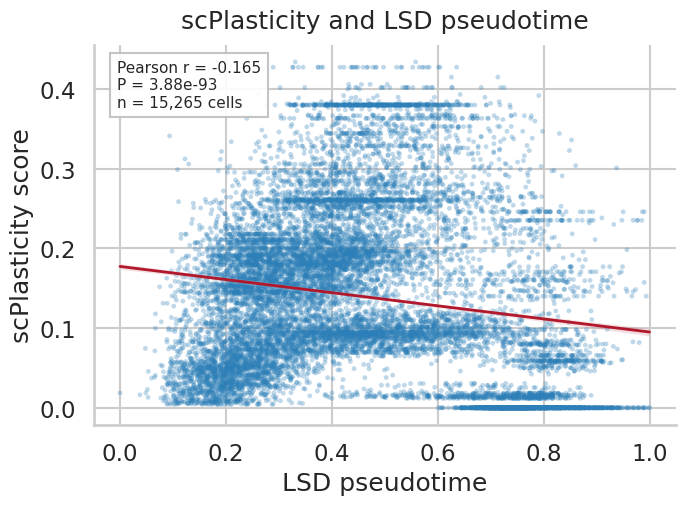

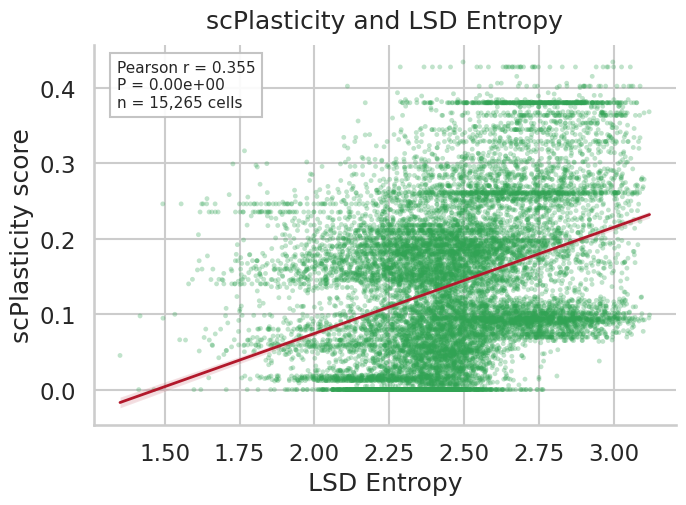

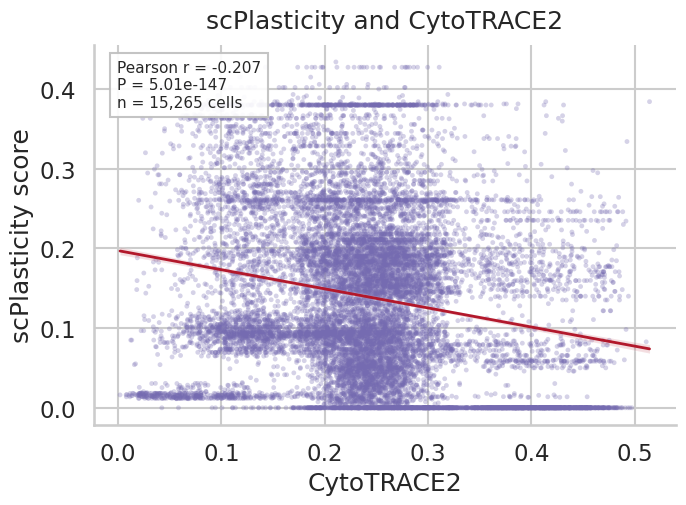

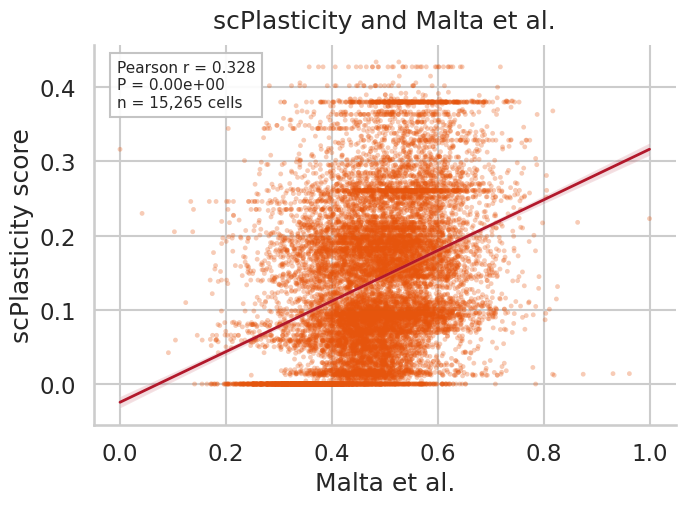

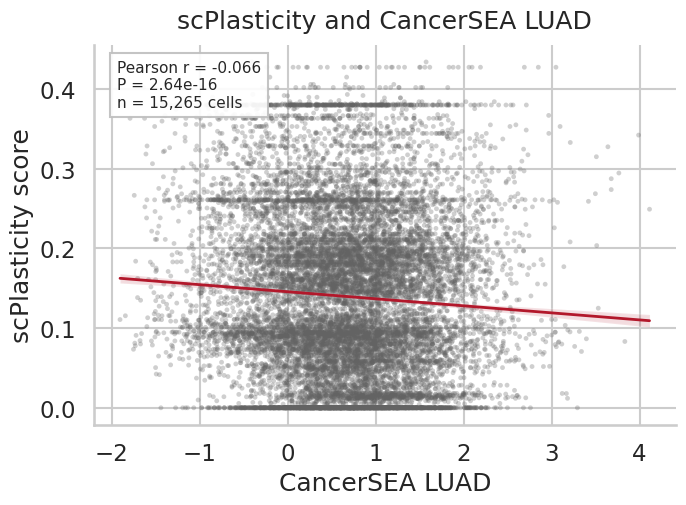

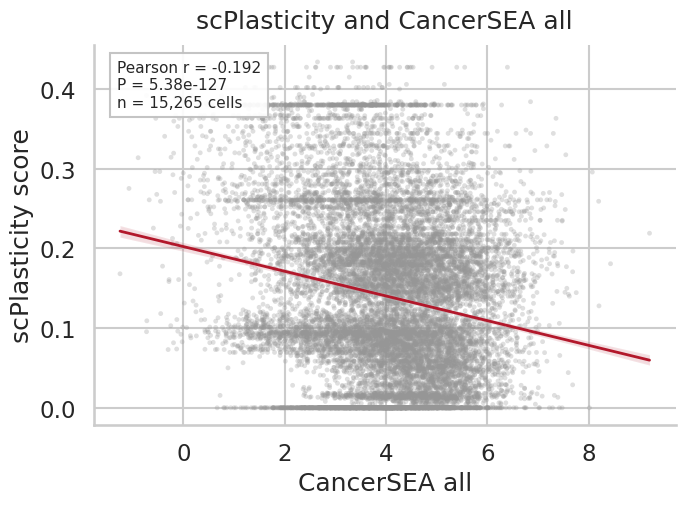

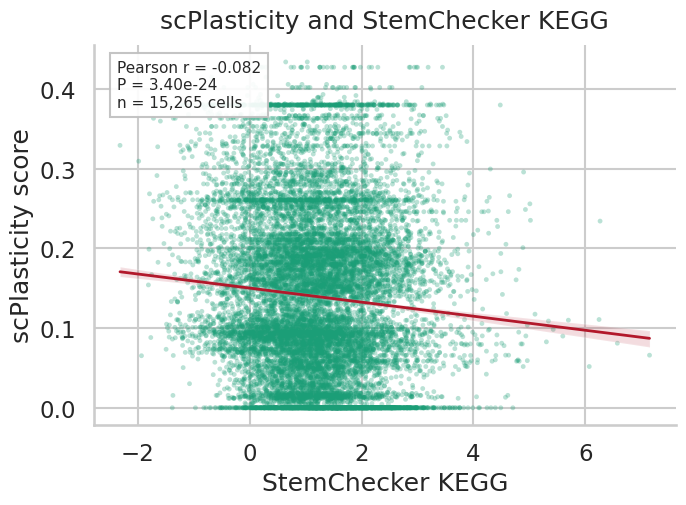

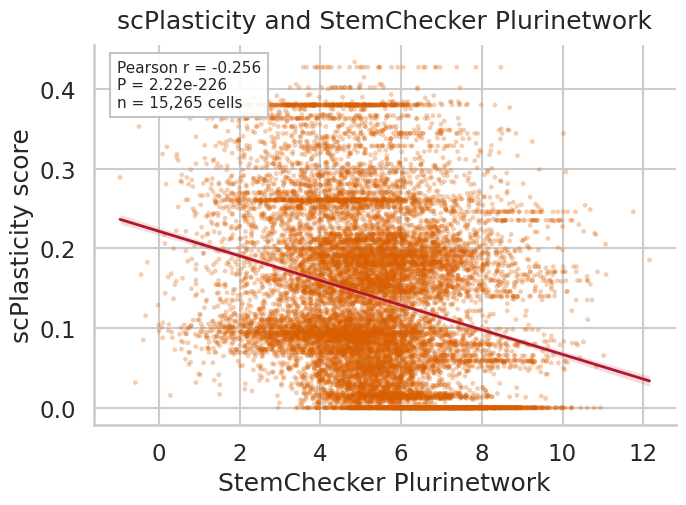

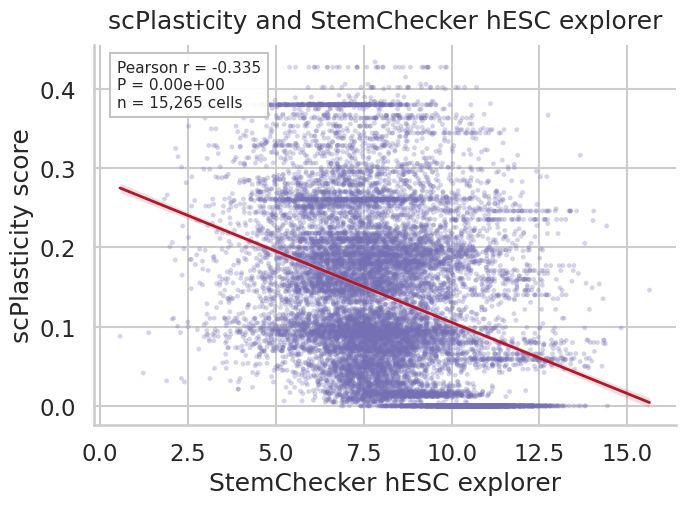

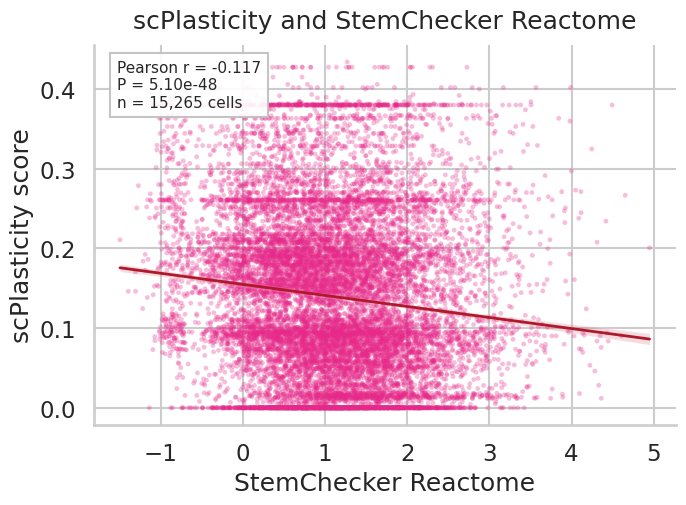

,method,comparison,column,pearson_r,pearson_p,n_cells
0,LSD pseudotime,LSD pseudotime,lsd_pseudotime,-0.164573,3.876027e-93,15265
1,LSD Entropy,LSD Entropy,entropy,0.354587,0.000000e+00,15265
2,CytoTRACE2,CytoTRACE2,cytotrace2_score_full,-0.206753,5.011684e-147,15265
3,Malta et al.,Malta et al.,score_Malta_2018,0.327515,0.000000e+00,15265
4,CancerSEA LUAD,CancerSEA LUAD,CancerSEA_LUAD_Kim_2015,-0.066211,2.639879e-16,15265
5,CancerSEA all,CancerSEA all,CancerSEA_all,-0.192232,5.384691e-127,15265
6,StemChecker KEGG,StemChecker KEGG,StemChecker_KEGG,-0.082000,3.399636e-24,15265
7,StemChecker Plurinetwork,StemChecker Plurinetwork,StemChecker_Plurinetwork,-0.255672,2.216344e-226,15265
8,StemChecker hESC explorer,StemChecker hESC explorer,StemChecker_hscexplorer,-0.334875,0.000000e+00,15265
9,StemChecker Reactome,StemChecker Reactome,StemChecker_reactome,-0.117441,5.100622e-48,15265


In [6]:
corr_results = [
    plot_scplasticity_relationship(analysis_df, method)
    for method in METHOD_SPECS
]

corr_results_df = pd.DataFrame(corr_results)
display(corr_results_df)

## Bootstrap Pearson correlations

For each of 2,000 bootstrap iterations, cells are sampled with replacement and
Pearson correlation is recomputed for every method. Boxes show the interquartile
range, whiskers extend to 1.5 times that range, and diamonds show correlations
from the original filtered data.

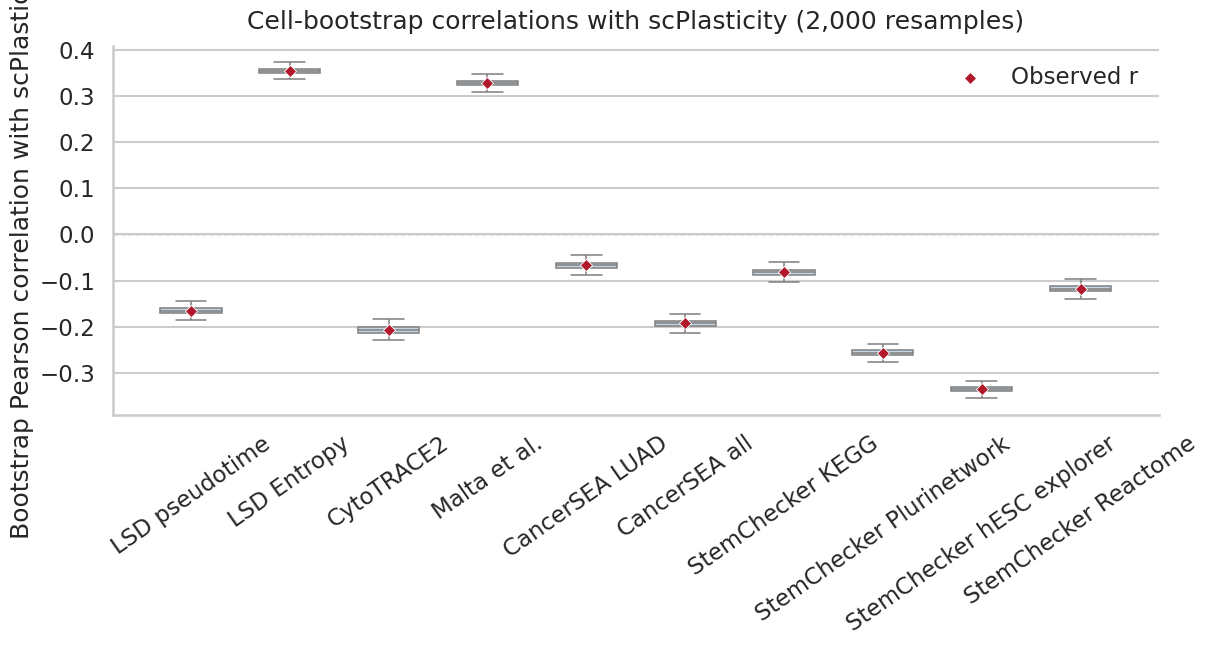

,observed_r,bootstrap_median,bootstrap_mean,ci_95_low,ci_95_high
method,,,,,
LSD pseudotime,-0.164573,-0.164559,-0.164759,-0.180600,-0.149703
LSD Entropy,0.354587,0.354414,0.354514,0.341768,0.368240
CytoTRACE2,-0.206753,-0.206426,-0.206510,-0.222188,-0.190339
Malta et al.,0.327515,0.327343,0.327493,0.313203,0.341881
CancerSEA LUAD,-0.066211,-0.066349,-0.066134,-0.081670,-0.049999
CancerSEA all,-0.192232,-0.192350,-0.192167,-0.206747,-0.176558
StemChecker KEGG,-0.082000,-0.081755,-0.081773,-0.096909,-0.065318
StemChecker Plurinetwork,-0.255672,-0.255664,-0.255654,-0.269692,-0.241519
StemChecker hESC explorer,-0.334875,-0.334861,-0.334853,-0.348987,-0.321016


In [7]:
bootstrap_corr_df = bootstrap_pearson_correlations(
    analysis_df,
    METHOD_SPECS,
)

method_order = [method["label"] for method in METHOD_SPECS]
observed_correlations = corr_results_df.set_index("method")["pearson_r"]

bootstrap_summary = (
    bootstrap_corr_df.groupby("method", sort=False)["pearson_r"]
    .agg(
        bootstrap_median="median",
        bootstrap_mean="mean",
        ci_95_low=lambda values: values.quantile(0.025),
        ci_95_high=lambda values: values.quantile(0.975),
    )
    .reindex(method_order)
)
bootstrap_summary.insert(
    0,
    "observed_r",
    observed_correlations.reindex(method_order),
)

fig, ax = plt.subplots(figsize=(12.5, 6.8))
sns.boxplot(
    data=bootstrap_corr_df,
    x="method",
    y="pearson_r",
    order=method_order,
    color="#BFD7EA",
    width=0.62,
    showfliers=False,
    linewidth=1.1,
    ax=ax,
)
ax.scatter(
    np.arange(len(method_order)),
    observed_correlations.reindex(method_order),
    marker="D",
    s=38,
    color="#B2182B",
    edgecolor="white",
    linewidth=0.6,
    zorder=4,
    label="Observed r",
)
ax.axhline(0, color="0.45", linestyle="--", linewidth=1.0, zorder=0)
ax.set_xlabel("")
ax.set_ylabel("Bootstrap Pearson correlation with scPlasticity (r)")
ax.set_title(
    f"Cell-bootstrap correlations with scPlasticity ({N_BOOTSTRAPS:,} resamples)",
    pad=12,
)
ax.tick_params(axis="x", rotation=35)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("center")
    label.set_rotation_mode("default")
ax.legend(frameon=False, loc="best")
sns.despine(ax=ax)
fig.tight_layout()
save_figure(fig, "pearson_bootstrap_boxplot")
plt.show()

display(bootstrap_summary)

## Regression models

We compare two nested models:

- **Null model:** `scPlasticity ~ lsd_pseudotime`
- **Full model:** `scPlasticity ~ lsd_pseudotime + entropy`

The full model is tested against the null model using a nested-model F test. We also compute bootstrap confidence intervals for the in-sample $R^2$ values.

In [8]:
# ------------------------------------------------------------------
# Prepare one shared dataset so every model uses identical observations
# ------------------------------------------------------------------
required_columns = [
    "scPlasticity",
    "lsd_pseudotime",
    "entropy",
    "score_Malta_2018",
]

model_df = analysis_df[required_columns].dropna().copy()
y = model_df["scPlasticity"].to_numpy()

# ------------------------------------------------------------------
# Define the four models
# ------------------------------------------------------------------
model_specs = {
    "M1: pseudotime": [
        "lsd_pseudotime",
    ],
    "M2: pseudotime + entropy": [
        "lsd_pseudotime",
        "entropy",
    ],
    "M3: pseudotime + Malta score": [
        "lsd_pseudotime",
        "score_Malta_2018",
    ],
    "M4: pseudotime + entropy + Malta score": [
        "lsd_pseudotime",
        "entropy",
        "score_Malta_2018",
    ],
}

model_formulas = {
    "M1: pseudotime":
        "scPlasticity ~ lsd_pseudotime",

    "M2: pseudotime + entropy":
        "scPlasticity ~ lsd_pseudotime + entropy",

    "M3: pseudotime + Malta score":
        "scPlasticity ~ lsd_pseudotime + score_Malta_2018",

    "M4: pseudotime + entropy + Malta score":
        "scPlasticity ~ lsd_pseudotime + entropy + score_Malta_2018",
}

# ------------------------------------------------------------------
# Fit all four OLS models
# ------------------------------------------------------------------
models = {}

for model_name, predictors in model_specs.items():
    X = sm.add_constant(model_df[predictors])
    models[model_name] = sm.OLS(y, X).fit()

# ------------------------------------------------------------------
# Bootstrap R² confidence intervals for all models
# Assumes bootstrap_r2_ci adds the intercept internally, as in your
# original code.
# ------------------------------------------------------------------
r2_intervals = {}

for model_name, predictors in model_specs.items():
    r2_intervals[model_name] = bootstrap_r2_ci(
        model_df[predictors].to_numpy(),
        y,
        model_formulas[model_name],
    )

# ------------------------------------------------------------------
# Overall model-fit summary
# AIC and BIC allow descriptive comparison of all four models,
# including M2 versus M3, which are not nested.
# ------------------------------------------------------------------
regression_summary = pd.DataFrame(
    [
        {
            "model": model_name,
            "formula": model_formulas[model_name],
            "n_obs": int(model.nobs),
            "n_predictors": len(model_specs[model_name]),
            "r2": float(model.rsquared),
            "adj_r2": float(model.rsquared_adj),
            "r2_ci_low": r2_intervals[model_name]["r2_ci_low"],
            "r2_ci_high": r2_intervals[model_name]["r2_ci_high"],
            "aic": float(model.aic),
            "bic": float(model.bic),
        }
        for model_name, model in models.items()
    ]
)

# ------------------------------------------------------------------
# Nested-model F-tests
#
# M2 versus M1: contribution of entropy
# M3 versus M1: contribution of Malta score
# M4 versus M2: contribution of Malta score after entropy
# M4 versus M3: contribution of entropy after Malta score
# M4 versus M1: joint contribution of entropy and Malta score
# ------------------------------------------------------------------
nested_comparisons = [
    {
        "comparison": "M2 vs M1",
        "reduced": "M1: pseudotime",
        "full": "M2: pseudotime + entropy",
        "terms_added": "entropy",
    },
    {
        "comparison": "M3 vs M1",
        "reduced": "M1: pseudotime",
        "full": "M3: pseudotime + Malta score",
        "terms_added": "score_Malta_2018",
    },
    {
        "comparison": "M4 vs M2",
        "reduced": "M2: pseudotime + entropy",
        "full": "M4: pseudotime + entropy + Malta score",
        "terms_added": "score_Malta_2018",
    },
    {
        "comparison": "M4 vs M3",
        "reduced": "M3: pseudotime + Malta score",
        "full": "M4: pseudotime + entropy + Malta score",
        "terms_added": "entropy",
    },
    {
        "comparison": "M4 vs M1",
        "reduced": "M1: pseudotime",
        "full": "M4: pseudotime + entropy + Malta score",
        "terms_added": "entropy + score_Malta_2018",
    },
]

comparison_rows = []

for comparison in nested_comparisons:
    reduced_model = models[comparison["reduced"]]
    full_model = models[comparison["full"]]

    f_stat, f_pvalue, df_diff = full_model.compare_f_test(reduced_model)

    comparison_rows.append(
        {
            "comparison": comparison["comparison"],
            "terms_added": comparison["terms_added"],
            "reduced_model": comparison["reduced"],
            "full_model": comparison["full"],
            "f_statistic": float(f_stat),
            "p_value": float(f_pvalue),
            "df_difference": int(df_diff),
            "delta_r2": float(
                full_model.rsquared - reduced_model.rsquared
            ),
            "delta_adj_r2": float(
                full_model.rsquared_adj - reduced_model.rsquared_adj
            ),
            "delta_aic": float(
                full_model.aic - reduced_model.aic
            ),
            "delta_bic": float(
                full_model.bic - reduced_model.bic
            ),
        }
    )

comparison_summary = pd.DataFrame(comparison_rows)

# ------------------------------------------------------------------
# Combine coefficient estimates and 95% confidence intervals
# ------------------------------------------------------------------
coefficient_tables = []

for model_name, model in models.items():
    confidence_intervals = model.conf_int()

    coefficient_table = pd.DataFrame(
        {
            "model": model_name,
            "term": model.params.index,
            "estimate": model.params.values,
            "std_error": model.bse.values,
            "t_statistic": model.tvalues.values,
            "p_value": model.pvalues.values,
            "ci_low": confidence_intervals[0].values,
            "ci_high": confidence_intervals[1].values,
        }
    )

    coefficient_tables.append(coefficient_table)

coefficient_summary = pd.concat(
    coefficient_tables,
    ignore_index=True,
)

# ------------------------------------------------------------------
# Display results
# ------------------------------------------------------------------
print("Model-fit summary:")
display(regression_summary)

print("Nested-model comparisons:")
display(comparison_summary)

print("Coefficient estimates with 95% confidence intervals:")
display(coefficient_summary)

Model-fit summary:


,model,formula,n_obs,n_predictors,r2,adj_r2,r2_ci_low,r2_ci_high,aic,bic
0,M1: pseudotime,scPlasticity ~ lsd_pseudotime,15265,1,0.027084,0.027021,0.022685,0.032708,-26257.864638,-26242.598002
1,M2: pseudotime + entropy,scPlasticity ~ lsd_pseudotime + entropy,15265,2,0.145959,0.145847,0.136447,0.156092,-28245.175090,-28222.275136
2,M3: pseudotime + Malta score,scPlasticity ~ lsd_pseudotime + score_Malta_2018,15265,2,0.114014,0.113897,0.105563,0.123972,-27684.602446,-27661.702492
3,M4: pseudotime + entropy + Malta score,scPlasticity ~ lsd_pseudotime + entropy + scor...,15265,3,0.196801,0.196643,0.186985,0.208166,-29180.081269,-29149.547998


Nested-model comparisons:


,comparison,terms_added,reduced_model,full_model,f_statistic,p_value,df_difference,delta_r2,delta_adj_r2,delta_aic,delta_bic
0,M2 vs M1,entropy,M1: pseudotime,M2: pseudotime + entropy,2124.333800,0.000000e+00,1,0.118875,0.118827,-1987.310452,-1979.677134
1,M3 vs M1,score_Malta_2018,M1: pseudotime,M3: pseudotime + Malta score,1497.441024,1.408613e-312,1,0.086929,0.086877,-1426.737808,-1419.104490
2,M4 vs M2,score_Malta_2018,M2: pseudotime + entropy,M4: pseudotime + entropy + Malta score,966.002171,1.069158e-205,1,0.050842,0.050796,-934.906180,-927.272862
3,M4 vs M3,entropy,M3: pseudotime + Malta score,M4: pseudotime + entropy + Malta score,1572.978886,0.000000e+00,1,0.082787,0.082745,-1495.478823,-1487.845505
4,M4 vs M1,entropy + score_Malta_2018,M1: pseudotime,M4: pseudotime + entropy + Malta score,1612.327818,0.000000e+00,2,0.169716,0.169622,-2922.216632,-2906.949996


Coefficient estimates with 95% confidence intervals:


,model,term,estimate,std_error,t_statistic,p_value,ci_low,ci_high
0,M1: pseudotime,const,0.177321,0.002003,88.545614,0.000000e+00,0.173396,0.181246
1,M1: pseudotime,lsd_pseudotime,-0.082346,0.003995,-20.613035,3.876027e-93,-0.090176,-0.074515
2,M2: pseudotime + entropy,const,-0.165838,0.007678,-21.598796,6.159775e-102,-0.180888,-0.150788
3,M2: pseudotime + entropy,lsd_pseudotime,-0.071308,0.003751,-19.012382,1.120794e-79,-0.078660,-0.063956
4,M2: pseudotime + entropy,entropy,0.137175,0.002976,46.090496,0.000000e+00,0.131341,0.143008
5,M3: pseudotime + Malta score,const,0.005986,0.004822,1.241302,2.145135e-01,-0.003466,0.015439
6,M3: pseudotime + Malta score,lsd_pseudotime,-0.042568,0.003948,-10.780902,5.300594e-27,-0.050307,-0.034829
7,M3: pseudotime + Malta score,score_Malta_2018,0.317753,0.008211,38.696783,0.000000e+00,0.301658,0.333849
8,M4: pseudotime + entropy + Malta score,const,-0.250243,0.007926,-31.572087,5.492228e-212,-0.265779,-0.234706
9,M4: pseudotime + entropy + Malta score,lsd_pseudotime,-0.041749,0.003760,-11.104610,1.532450e-28,-0.049119,-0.034380


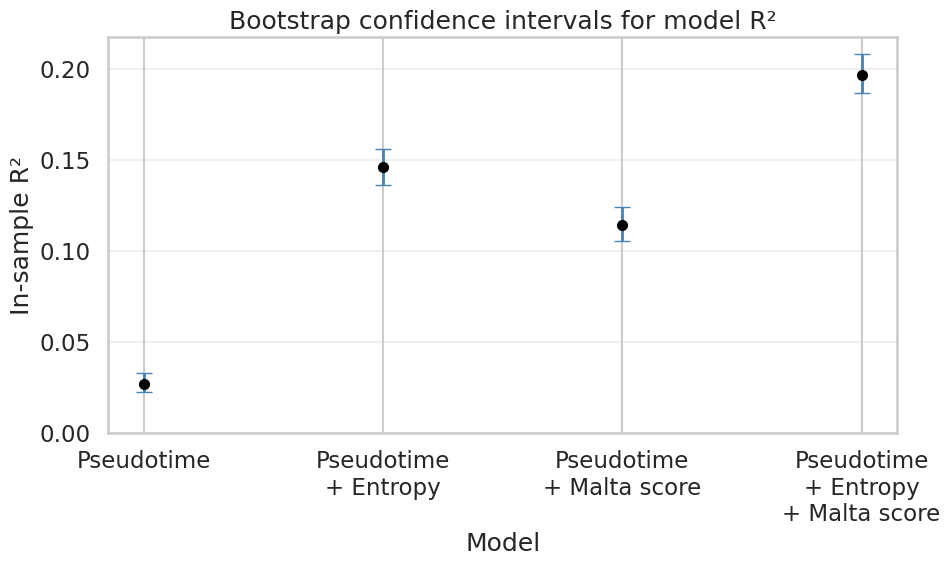

In [9]:
# Visualize the in-sample R² values together with bootstrap confidence intervals.
r2_plot_df = regression_summary.copy()

# These labels correspond to models M1–M4 in regression_summary.
r2_plot_df["label"] = [
    "Pseudotime",
    "Pseudotime\n+ Entropy",
    "Pseudotime\n+ Malta score",
    "Pseudotime\n+ Entropy\n+ Malta score",
]

# Calculate asymmetric confidence-interval distances.
lower_errors = r2_plot_df["r2"] - r2_plot_df["r2_ci_low"]
upper_errors = r2_plot_df["r2_ci_high"] - r2_plot_df["r2"]

fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(
    x=r2_plot_df["label"],
    y=r2_plot_df["r2"],
    yerr=np.vstack([lower_errors, upper_errors]),
    fmt="o",
    color="black",
    ecolor="steelblue",
    markersize=7,
    elinewidth=2,
    capsize=6,
)

ax.set_xlabel("Model")
ax.set_ylabel("In-sample R²")
ax.set_title("Bootstrap confidence intervals for model R²")

ax.set_ylim(
    bottom=min(
        0,
        r2_plot_df["r2_ci_low"].min() - 0.02,
    )
)

ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
save_figure(fig, "model_r2_bootstrap_ci")
plt.show()

## Cross-validation

To confirm that the model comparison is not just an in-sample effect, we compute 5-fold cross-validated $R^2$ values for both models.

,model,cv_mean_r2,cv_std_r2,cv_min_r2,cv_max_r2
0,M1: Pseudotime,0.026405,0.010031,0.014120,0.040542
1,M2: Pseudotime + entropy,0.145332,0.005452,0.138688,0.153646
2,M3: Pseudotime + Malta score,0.113094,0.015715,0.102213,0.140776
3,M4: Pseudotime + entropy + Malta score,0.196035,0.011771,0.186121,0.215546


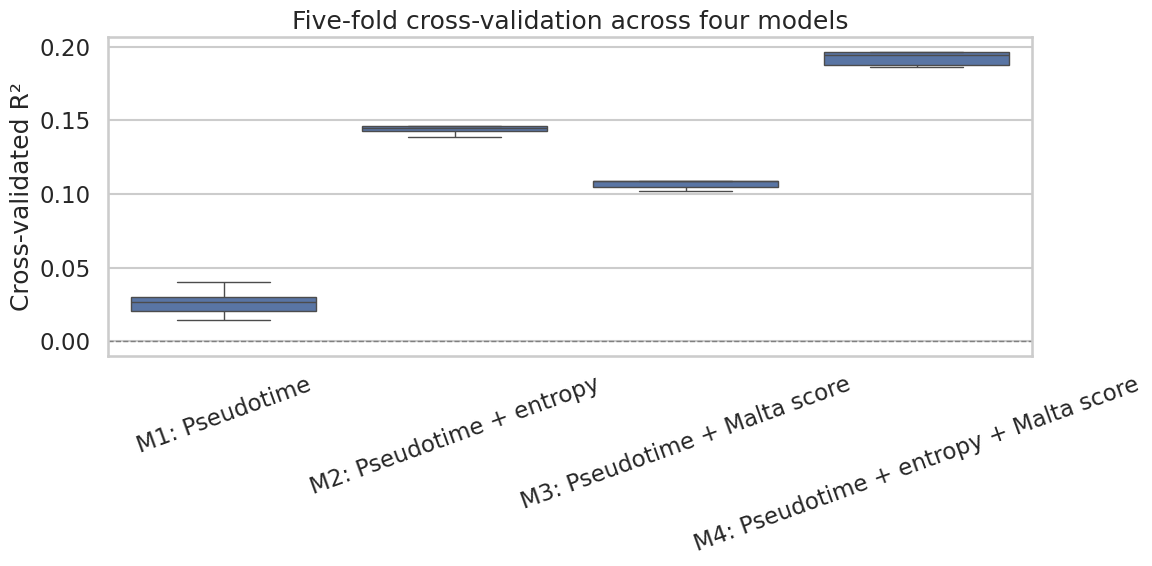

In [10]:
# ------------------------------------------------------------------
# Calculate cross-validated R² scores for all four models
# ------------------------------------------------------------------
cv_model_labels = {
    "M1: pseudotime": "M1: Pseudotime",
    "M2: pseudotime + entropy": "M2: Pseudotime + entropy",
    "M3: pseudotime + Malta score": "M3: Pseudotime + Malta score",
    "M4: pseudotime + entropy + Malta score":
        "M4: Pseudotime + entropy + Malta score",
}

cv_results = []

for model_name, predictors in model_specs.items():
    X = model_df[predictors].to_numpy()

    model_cv_df = cv_r2_scores(
        X,
        y,
        cv_model_labels[model_name],
    )

    cv_results.append(model_cv_df)

cv_results_df = pd.concat(cv_results, ignore_index=True)

# Set an explicit model order for summaries and plots.
model_order = list(cv_model_labels.values())

cv_results_df["model"] = pd.Categorical(
    cv_results_df["model"],
    categories=model_order,
    ordered=True,
)

# ------------------------------------------------------------------
# Summarize cross-validated R² across folds
# ------------------------------------------------------------------
cv_summary = (
    cv_results_df.groupby(
        "model",
        observed=True,
    )["fold_r2"]
    .agg(["mean", "std", "min", "max"])
    .rename(
        columns={
            "mean": "cv_mean_r2",
            "std": "cv_std_r2",
            "min": "cv_min_r2",
            "max": "cv_max_r2",
        }
    )
    .reset_index()
)

display(cv_summary)

# ------------------------------------------------------------------
# Visualize fold-level cross-validated R² values
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=cv_results_df,
    x="model",
    y="fold_r2",
    order=model_order,
    showfliers=False,
    ax=ax,
)

# R² = 0 means performance equivalent to predicting the training-fold mean.
ax.axhline(
    y=0,
    color="gray",
    linestyle="--",
    linewidth=1,
)

ax.set_xlabel("")
ax.set_ylabel("Cross-validated R²")
ax.set_title("Five-fold cross-validation across four models")
ax.tick_params(axis="x", rotation=20)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("center")
    label.set_rotation_mode("default")

fig.tight_layout()
save_figure(fig, "cv_r2_boxplot")
plt.show()

## Result checklist

The outputs report:

- observed Pearson correlations for all ten stemness methods
- cell-bootstrap Pearson correlation distributions and percentile summaries
- model $R^2$ values and bootstrap confidence intervals
- nested-model F tests
- five-fold cross-validated $R^2$ values

In [11]:
# ------------------------------------------------------------------
# Identify the strongest absolute Pearson correlation
# ------------------------------------------------------------------
best_corr = corr_results_df.iloc[
    corr_results_df["pearson_r"].abs().argmax()
]

# ------------------------------------------------------------------
# Cross-validation model labels used in the previous code
# ------------------------------------------------------------------
cv_labels = {
    "M1": "M1: Pseudotime",
    "M2": "M2: Pseudotime + entropy",
    "M3": "M3: Pseudotime + Malta score",
    "M4": "M4: Pseudotime + entropy + Malta score",
}

# Create a convenient lookup for mean cross-validated R².
cv_mean_lookup = (
    cv_summary
    .set_index("model")["cv_mean_r2"]
    .astype(float)
    .to_dict()
)

# Cross-validated improvements for the nested comparisons.
cv_deltas = {
    "M2 vs M1": (
        cv_mean_lookup[cv_labels["M2"]]
        - cv_mean_lookup[cv_labels["M1"]]
    ),
    "M3 vs M1": (
        cv_mean_lookup[cv_labels["M3"]]
        - cv_mean_lookup[cv_labels["M1"]]
    ),
    "M4 vs M2": (
        cv_mean_lookup[cv_labels["M4"]]
        - cv_mean_lookup[cv_labels["M2"]]
    ),
    "M4 vs M3": (
        cv_mean_lookup[cv_labels["M4"]]
        - cv_mean_lookup[cv_labels["M3"]]
    ),
    "M4 vs M1": (
        cv_mean_lookup[cv_labels["M4"]]
        - cv_mean_lookup[cv_labels["M1"]]
    ),
}

# Identify the model with the highest mean cross-validated R².
best_cv_row = cv_summary.loc[
    cv_summary["cv_mean_r2"].astype(float).idxmax()
]

# ------------------------------------------------------------------
# Print analysis summary
# ------------------------------------------------------------------
print("Summary of B2 cancer analysis")
print("=" * 60)

print(f"Filtered analysis cells: {len(analysis_df):,}")
print(f"Complete-case cells used in all regressions: {len(model_df):,}")
print(f"Valid clusters used in regression: {len(valid_clusters)}")

# ------------------------------------------------------------------
# Correlation results
# ------------------------------------------------------------------
print()
print("Correlation results")
print("-" * 60)

for _, row in corr_results_df.iterrows():
    print(
        f"- {row['comparison']}: "
        f"r = {row['pearson_r']:.3f}, "
        f"p = {row['pearson_p']:.3e}, "
        f"n = {int(row['n_cells'])}"
    )

# ------------------------------------------------------------------
# Regression fit results
# ------------------------------------------------------------------
print()
print("Regression results")
print("-" * 60)

for _, row in regression_summary.iterrows():
    print(
        f"- {row['model']}: "
        f"R² = {row['r2']:.4f}, "
        f"adjusted R² = {row['adj_r2']:.4f}, "
        f"95% bootstrap CI = "
        f"[{row['r2_ci_low']:.4f}, {row['r2_ci_high']:.4f}], "
        f"AIC = {row['aic']:.2f}, "
        f"BIC = {row['bic']:.2f}"
    )

# ------------------------------------------------------------------
# Nested-model comparisons
# ------------------------------------------------------------------
print()
print("Nested-model comparisons")
print("-" * 60)

for _, row in comparison_summary.iterrows():
    print(
        f"- {row['comparison']} "
        f"(adding {row['terms_added']}): "
        f"F = {row['f_statistic']:.4f}, "
        f"p = {row['p_value']:.3e}, "
        f"df difference = {int(row['df_difference'])}, "
        f"ΔR² = {row['delta_r2']:.4f}, "
        f"Δ adjusted R² = {row['delta_adj_r2']:.4f}"
    )

# ------------------------------------------------------------------
# Cross-validation results
# ------------------------------------------------------------------
print()
print("Five-fold cross-validation")
print("-" * 60)

for _, row in cv_summary.iterrows():
    print(
        f"- {row['model']}: "
        f"mean CV R² = {row['cv_mean_r2']:.4f}, "
        f"SD = {row['cv_std_r2']:.4f}, "
        f"range = "
        f"[{row['cv_min_r2']:.4f}, {row['cv_max_r2']:.4f}]"
    )

print()
print("Cross-validated model differences")

for comparison, delta in cv_deltas.items():
    print(f"- {comparison}: Δ mean CV R² = {delta:.4f}")

# ------------------------------------------------------------------
# Main findings
# ------------------------------------------------------------------
print()
print("Main findings")
print("-" * 60)

print(
    f"- Strongest filtered Pearson association: "
    f"{best_corr['comparison']} "
    f"(r = {best_corr['pearson_r']:.3f}, "
    f"p = {best_corr['pearson_p']:.3e})"
)

print(
    f"- Best cross-validated model: {best_cv_row['model']} "
    f"(mean CV R² = {best_cv_row['cv_mean_r2']:.4f})"
)

print(
    f"- Full-model improvement over pseudotime alone: "
    f"Δ mean CV R² = {cv_deltas['M4 vs M1']:.4f}"
)

print()
print("Bootstrap Pearson correlation summary")
print("-" * 60)
display(bootstrap_summary)

Summary of B2 cancer analysis
Filtered analysis cells: 15,265
Complete-case cells used in all regressions: 15,265
Valid clusters used in regression: 8

Correlation results
------------------------------------------------------------
- LSD pseudotime: r = -0.165, p = 3.876e-93, n = 15265
- LSD Entropy: r = 0.355, p = 0.000e+00, n = 15265
- CytoTRACE2: r = -0.207, p = 5.012e-147, n = 15265
- Malta et al.: r = 0.328, p = 0.000e+00, n = 15265
- CancerSEA LUAD: r = -0.066, p = 2.640e-16, n = 15265
- CancerSEA all: r = -0.192, p = 5.385e-127, n = 15265
- StemChecker KEGG: r = -0.082, p = 3.400e-24, n = 15265
- StemChecker Plurinetwork: r = -0.256, p = 2.216e-226, n = 15265
- StemChecker hESC explorer: r = -0.335, p = 0.000e+00, n = 15265
- StemChecker Reactome: r = -0.117, p = 5.101e-48, n = 15265

Regression results
------------------------------------------------------------
- M1: pseudotime: R² = 0.0271, adjusted R² = 0.0270, 95% bootstrap CI = [0.0227, 0.0327], AIC = -26257.86, BIC = -26

,observed_r,bootstrap_median,bootstrap_mean,ci_95_low,ci_95_high
method,,,,,
LSD pseudotime,-0.164573,-0.164559,-0.164759,-0.180600,-0.149703
LSD Entropy,0.354587,0.354414,0.354514,0.341768,0.368240
CytoTRACE2,-0.206753,-0.206426,-0.206510,-0.222188,-0.190339
Malta et al.,0.327515,0.327343,0.327493,0.313203,0.341881
CancerSEA LUAD,-0.066211,-0.066349,-0.066134,-0.081670,-0.049999
CancerSEA all,-0.192232,-0.192350,-0.192167,-0.206747,-0.176558
StemChecker KEGG,-0.082000,-0.081755,-0.081773,-0.096909,-0.065318
StemChecker Plurinetwork,-0.255672,-0.255664,-0.255654,-0.269692,-0.241519
StemChecker hESC explorer,-0.334875,-0.334861,-0.334853,-0.348987,-0.321016
